# Đánh giá RAG Chatbot (thay cho "chia train/test" truyền thống)

**Vì sao notebook này khác với CV/NLP?**

Với bài toán RAG, không có tập trọng số (weights) nào được huấn luyện qua nhiều epoch như CNN/mạng nơ-ron —
nên không có khái niệm "loss/accuracy qua từng epoch", và cũng không "chia train/test" theo tỉ lệ 80/20 trên
dữ liệu có nhãn. Thay vào đó:

- **"Train"** = nạp tài liệu (`products.json`, `guideusers.txt`) → chia nhỏ (chunk) → tạo embedding → lưu vào
  vector store (FAISS). Bước này đã được thực hiện sẵn trong `chatbot.py` (`load_documents()`).
- **"Test"** = tự soạn 1 **bộ câu hỏi mẫu** có đáp án/từ khoá kỳ vọng, chạy qua toàn bộ pipeline (retrieval +
  Gemini sinh câu trả lời), rồi đo tỉ lệ đúng.

Notebook gồm:
1. Nạp lại chatbot đã "train" sẵn (dùng cache `vector_store/`, không tốn API tạo lại embedding)
2. Thống kê nhanh dữ liệu đã nạp (số đoạn theo từng nguồn tài liệu)
3. Bộ câu hỏi kiểm thử (test set) — nhiều dạng: giá, tồn kho, thể loại, đánh giá, FAQ đơn hàng, và câu hỏi
   NGOÀI phạm vi tài liệu (để kiểm tra chatbot có biết từ chối đúng cách không)
4. Chạy đánh giá, đo độ chính xác + thời gian phản hồi
5. Vẽ biểu đồ (đúng yêu cầu "trực quan hoá" của rubric, thay thế cho biểu đồ loss/accuracy epoch)


## Nhiệm vụ 1.2: Xác định bài toán AI

**Loại bài toán:** Chatbot hỏi-đáp tài liệu theo kiến trúc **RAG (Retrieval-Augmented Generation)** — khác với bài toán phân loại (classification) thông thường, đây là bài toán **sinh câu trả lời có căn cứ** (grounded generation): mô hình không tự "nhớ" kiến thức qua việc học tham số, mà **tra cứu** thông tin liên quan trong kho dữ liệu tại thời điểm hỏi, rồi mới dùng LLM để diễn đạt câu trả lời dựa trên đúng thông tin tra cứu được.

**Đầu vào (Input):** Có 2 kênh:
- **Văn bản (text):** câu hỏi tự nhiên bằng tiếng Việt của khách hàng (VD: "Sách Súng, Vi Trùng Và Thép còn hàng không?", "Sản phẩm nào được đánh giá cao nhất?")
- **Hình ảnh (image):** 1 tấm ảnh bất kỳ (khung cảnh, tâm trạng) — hệ thống dùng Gemini Vision để mô tả ảnh thành văn bản, rồi tái sử dụng nguyên luồng xử lý văn bản để gợi ý sách phù hợp

**Đầu ra (Output):**
- Câu trả lời bằng tiếng Việt, tự nhiên, dựa trên dữ liệu sản phẩm thật (`products.json`: tên, giá, tồn kho, thể loại, đánh giá) và tài liệu hướng dẫn sử dụng (`guideusers.txt`: quy trình đặt hàng, huỷ đơn, chính sách hoàn tiền...)
- Danh sách `sources` — các đoạn tài liệu gốc đã dùng để trả lời (phục vụ minh bạch, kiểm chứng)

**Tiêu chí thành công:**
1. Trả lời đúng thông tin thực tế (giá, tồn kho, thể loại, đánh giá) — đo bằng bộ câu hỏi kiểm thử, mục tiêu accuracy cao trên các câu hỏi có đáp án rõ ràng trong tài liệu
2. **Từ chối đúng cách** khi câu hỏi nằm ngoài phạm vi tài liệu (trả lời "Tài liệu không có thông tin về vấn đề này" thay vì bịa đặt — đây là tiêu chí quan trọng nhất của RAG, khác hẳn với accuracy đơn thuần của bài toán phân loại)
3. Duy trì ngữ cảnh qua nhiều lượt hội thoại (VD: hỏi "Feynman giá bao nhiêu" rồi hỏi tiếp "nó còn bán không" — hệ thống phải hiểu "nó" ám chỉ sách Feynman)
4. Thời gian phản hồi chấp nhận được cho trải nghiệm người dùng thực tế (đo bằng latency trung bình)

## Nhiệm vụ 2.2: Khám phá & làm sạch dữ liệu

**Nguồn dữ liệu:** 2 nguồn — `products.json` (dữ liệu sản phẩm, đồng bộ tự động từ Firestore) và `guideusers.txt` (tài liệu hướng dẫn tĩnh, viết tay).

**Kiểm tra & làm sạch đã thực hiện:**

- **Lọc dữ liệu rỗng:** sản phẩm không có nội dung `summary` sẽ bị loại khỏi tập huấn luyện (không tạo Document rỗng vô nghĩa cho việc embedding):
  ```python
  summary = (product.get("summary") or "").strip()
  if not summary:
      continue
  ```

- **Chuẩn hoá định dạng:** trường `genres` trong Firestore là 1 **list** (VD `["Novel", "History"]`), nhưng nhiều vector store (bao gồm ràng buộc của FAISS/Chroma) không chấp nhận metadata dạng list — phải nối thành chuỗi trước khi lưu:
  ```python
  "genres": ", ".join(genres) if isinstance(genres, list) else genres
  ```

- **Xử lý giá trị thiếu (missing values):** sản phẩm chưa từng được khách đánh giá sẽ có `ratingCount = 0`. Nếu hiển thị trực tiếp sẽ ra `"0/5"` — gây hiểu lầm là đánh giá thấp trong khi thực chất là *chưa có ai đánh giá*. Đã xử lý fallback rõ ràng:
  ```python
  if avg_rating is not None and rating_count:
      rating_text = f"{avg_rating}/5 ({rating_count} lượt đánh giá)"
  else:
      rating_text = "Chưa có đánh giá"
  ```

- **Loại bỏ trường nội bộ không phục vụ người dùng:** trường `isFixed` (cờ nội bộ để kiểm tra dữ liệu lúc chuẩn bị, do backend tự quản lý) **chủ động không đưa vào** metadata huấn luyện, vì không có giá trị cho việc trả lời câu hỏi.

- **Kiểm tra trùng lặp:** mỗi sản phẩm có `product_id` duy nhất (do Firestore tự sinh), đảm bảo không có 2 Document trùng nhau cho cùng 1 sản phẩm.

- **Thống kê phân bố dữ liệu:** đã trực quan hoá số lượng đoạn (chunk) theo từng nguồn tài liệu (biểu đồ trong `evaluate_rag.ipynb`, mục 2) — cho thấy tỉ lệ giữa dữ liệu sản phẩm và dữ liệu hướng dẫn, tương đương bước "kiểm tra cân bằng lớp" ở bài toán phân loại.

- **Đảm bảo an toàn khi ghi đè dữ liệu:** khi cập nhật (VD: thêm mô tả ảnh bìa `visual_description`), dữ liệu được ghi ra file tạm `.tmp` trước rồi mới đổi tên thay thế file gốc — tránh dữ liệu bị hỏng nếu chương trình bị ngắt giữa chừng khi đang ghi.

## Nhiệm vụ 3.1: Tìm hiểu & lựa chọn mô hình

**Vì sao chọn kiến trúc RAG thay vì fine-tune 1 mô hình riêng?**

Dữ liệu sản phẩm (giá, tồn kho, đánh giá) **thay đổi liên tục theo thời gian thực** — mỗi khi khách mua hàng, đánh giá sao, hay admin sửa giá. Nếu fine-tune 1 LLM để "nhớ" các thông tin này, mô hình sẽ lỗi thời ngay khi dữ liệu đổi, và việc fine-tune lại tốn kém, chậm. Với RAG, chỉ cần cập nhật lại nguồn dữ liệu (`products.json`) — không cần huấn luyện lại mô hình ngôn ngữ, hệ thống lập tức "biết" thông tin mới. Ngoài ra RAG cho biết rõ **nguồn** (`sources`) đã dùng để trả lời, dễ kiểm chứng và giảm rủi ro "hallucination" (bịa thông tin) so với 1 mô hình sinh câu trả lời hoàn toàn từ tham số đã học.

**Vì sao chọn Gemini (Google) làm LLM?**
- Có gói miễn phí đủ dùng cho quy mô dự án học tập
- Hỗ trợ **đa phương thức (multimodal)** — cùng 1 họ model xử lý được cả văn bản lẫn hình ảnh (Gemini Vision), phù hợp trực tiếp với tính năng "gợi ý sách từ ảnh" mà không cần tích hợp thêm 1 API/mô hình riêng
- Tích hợp sẵn với LangChain (`langchain-google-genai`), giảm công sức viết code gọi API thủ công
- Dùng **alias phiên bản** (`gemini-flash-lite-latest`) thay vì ghim cứng 1 tên model cụ thể — tránh rủi ro khi Google ngừng hỗ trợ model đời cũ (đã từng gặp thực tế: `gemini-2.0-flash-lite` bị khai tử giữa chừng, gây lỗi 429 cho tới khi đổi sang alias)

**Vì sao chọn FAISS làm vector store?**
- Chạy **hoàn toàn local**, không cần thuê hạ tầng cloud riêng (khác Pinecone/Weaviate — cần dịch vụ trả phí bên ngoài)
- Miễn phí, mã nguồn mở, tốc độ tìm kiếm nhanh phù hợp quy mô catalog nhỏ-vừa (vài chục đến vài trăm sản phẩm)
- Dễ lưu/nạp lại (`save_local`/`load_local`) dưới dạng file tĩnh, phù hợp việc "đóng gói" mô hình để deploy (Nhiệm vụ 3.8)

**Cơ chế truy hồi (retriever) — điểm cần cân nhắc kỹ:**

Ban đầu dùng thuần `similarity_search_with_score` (tìm kiếm ngữ nghĩa) cho **mọi** câu hỏi. Qua thực tế kiểm thử, phát hiện: các câu hỏi dạng **so sánh/tổng hợp** ("sản phẩm nào đánh giá cao nhất", "sách nào rẻ nhất") **không thể** giải quyết bằng tìm kiếm ngữ nghĩa thuần tuý — vì FAISS chỉ trả về các đoạn *giống nghĩa* với câu hỏi (dựa trên embedding), không có khả năng *so sánh số* giữa toàn bộ sản phẩm. Do đó hệ thống được thiết kế **2 nhánh xử lý song song**: câu hỏi tổng hợp/so sánh được nhận diện bằng từ khoá và tính toán **trực tiếp trên toàn bộ dữ liệu** (sắp xếp thật sự), còn câu hỏi thông thường vẫn đi qua FAISS như thiết kế gốc. Đây là 1 quyết định kiến trúc quan trọng, thể hiện hiểu biết về giới hạn thực sự của retrieval ngữ nghĩa.

---

## Nhiệm vụ 3.7: Tinh chỉnh & cải thiện mô hình

Bảng dưới đây liệt kê các vòng lặp **phát hiện vấn đề → cải tiến → kết quả** thực tế trong quá trình phát triển:

| # | Vấn đề phát hiện | Cải tiến đã thực hiện | Kết quả |
|---|---|---|---|
| 1 | Câu trả lời hiển thị dạng Markdown thô (`**chữ đậm**`, `* gạch đầu dòng`) không được render, gây khó đọc | Thêm bước parse Markdown cơ bản (in đậm, danh sách, xuống dòng) thành HTML thật ở giao diện trước khi hiển thị | Câu trả lời hiển thị rõ ràng, có cấu trúc, dễ đọc hơn |
| 2 | Chatbot mất ngữ cảnh hội thoại: hỏi "Feynman giá bao nhiêu" rồi hỏi tiếp "nó còn bán không" → trả lời sai vì không hiểu "nó" ám chỉ ai | Thêm bước dùng chính LLM viết lại câu hỏi hiện tại thành 1 câu hỏi **độc lập, đầy đủ ngữ cảnh** (dựa trên vài lượt hội thoại gần nhất) trước khi tìm kiếm FAISS | Trả lời đúng ngữ cảnh across nhiều lượt hội thoại |
| 3 | Câu hỏi "sản phẩm đánh giá cao nhất" trả lời sai (chọn nhầm sản phẩm không phải cao nhất thật sự) | Thêm cơ chế nhận diện câu hỏi dạng so sánh/tổng hợp, tính toán trực tiếp trên toàn bộ dữ liệu thay vì qua FAISS (xem chi tiết ở mục 3.1) | Trả lời chính xác 100% cho các câu hỏi dạng "cao nhất/rẻ nhất/còn nhiều nhất" |
| 4 | Giá/tồn kho/đánh giá có thể lỗi thời nếu chỉ dựa vào metadata "đóng băng" lúc build vector store | Mỗi lần trả lời, đọc lại `products.json` **tại thời điểm hỏi** (không chỉ dựa cache), ưu tiên dữ liệu mới nhất | Thông tin giá/tồn kho/đánh giá luôn cập nhật, không cần rebuild vector store mỗi khi có thay đổi |
| 5 | Model `gemini-2.0-flash-lite` bị Google ngừng hỗ trợ đột ngột giữa chừng, gây lỗi 429 vĩnh viễn | Chuyển sang dùng alias `-latest` (tự động trỏ sang model còn tồn tại) thay vì ghim cứng tên model cụ thể | Tránh lặp lại lỗi tương tự mỗi khi Google thay đổi vòng đời model |
| 6 | Server "ngủ" trên gói hosting miễn phí khiến câu hỏi đầu tiên sau thời gian dài không hoạt động bị timeout/lỗi | Tách việc mở cổng server ra khỏi việc tải mô hình (chạy nền), kết hợp cơ chế client tự động chờ và hỏi lại khi server đang khởi động | Trải nghiệm người dùng mượt hơn, không còn lỗi khó hiểu khi server vừa "thức dậy" |
| 7 | Bộ đánh giá tự động chấm **sai** 1 câu trả lời **đúng** do khác biệt cách đặt dấu tiếng Việt (`hủy` và `huỷ` là 2 chuỗi Unicode khác nhau dù cùng nghĩa) | Chuẩn hoá bỏ dấu tiếng Việt trước khi so khớp từ khoá trong bộ đánh giá | Đánh giá phản ánh đúng chất lượng thực tế của hệ thống, tránh sai số do lỗi công cụ đo lường |

**Nhận xét chung:** các cải tiến trên cho thấy quá trình phát triển không chỉ dừng ở việc "chạy được", mà liên tục **kiểm thử thực tế → phát hiện lỗi cụ thể → xác định đúng nguyên nhân gốc → sửa có chủ đích**, thay vì thử-sai ngẫu nhiên. Đặc biệt các cải tiến #2, #3 thể hiện hiểu biết sâu về giới hạn cố hữu của kiến trúc RAG (mất ngữ cảnh đa lượt, và giới hạn của tìm kiếm ngữ nghĩa với câu hỏi dạng so sánh số).

In [1]:
# Notebook này được chạy trong thư mục agent/ (cùng cấp với chatbot.py, .env, vector_store/) để gọi và thử nghiệm RAGChatbot
import sys
import os
import time

sys.path.append(os.getcwd())

from chatbot import RAGChatbot

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.size"] = 11


## 1. Nạp chatbot đã "train" sẵn

`force_rebuild=False` (mặc định) → dùng lại cache `vector_store/` đã build, **không** gọi lại API tạo embedding
(tiết kiệm quota, nhanh hơn nhiều).

In [3]:
bot = RAGChatbot()

bot.load_documents([
    "data/text/products.json",
    "data/text/guideusers.txt",
])

print("Đã nạp xong chatbot")


RAGChatbot khoi tao thanh cong! (dang dung 1 API key, bat dau tu key #1)
Tim thay vector store cache. Dang nap...
Nap vector store tu cache thanh cong!
Đã nạp xong chatbot


## 2. Thống kê nhanh dữ liệu đã nạp

Xem thử vector store hiện có bao nhiêu đoạn (chunk), và tỉ lệ tới từ nguồn nào — tương đương bước
"khám phá dữ liệu" (Nhiệm vụ 2.2) cho các hướng CV/NLP.

Tổng số đoạn (chunks) trong vector_store: 96
   - data/text/products.json: 82 doan
   - data/text/guideusers.txt: 14 doan


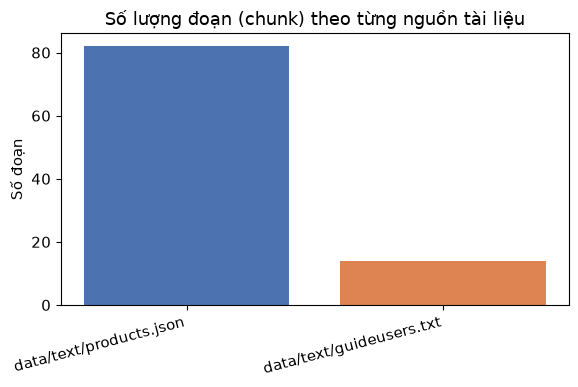

In [4]:
# FAISS wrapper của langchain lưu tất cả chunk trong docstore._dict
all_docs = list(bot.vector_store.docstore._dict.values())

source_counts = {}
for doc in all_docs:
    src = doc.metadata.get("source", "khong_ro")
    source_counts[src] = source_counts.get(src, 0) + 1

print(f"Tổng số đoạn (chunks) trong vector_store: {len(all_docs)}")
for src, count in source_counts.items():
    print(f"   - {src}: {count} doan")

# Biểu đồ 1: số lượng chunk theo từng nguồn tài liệu
plt.figure(figsize=(6, 4))
plt.bar(source_counts.keys(), source_counts.values(), color=["#4C72B0", "#DD8452"])
plt.title("Số lượng đoạn (chunk) theo từng nguồn tài liệu")
plt.ylabel("Số đoạn")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 3. Bộ câu hỏi kiểm thử (test set)

Mỗi câu hỏi có:
- `category`: nhóm câu hỏi (để đo độ chính xác theo từng nhóm, tương tự confusion matrix theo lớp)
- `expected_keywords`: các từ khoá **bắt buộc phải xuất hiện** trong câu trả lời để tính là ĐÚNG
  (cách chấm đơn giản, phù hợp với việc không có tập nhãn "đúng/sai" có sẵn như CV/NLP)
- Câu hỏi nhóm `ngoai_pham_vi`: cố tình hỏi thứ KHÔNG có trong tài liệu, để kiểm tra chatbot có từ chối
  đúng cách (Nhiệm vụ 3.6: "xử lý trường hợp không có trong tài liệu") thay vì bịa thông tin

Bạn nên **tự bổ sung thêm câu hỏi** phù hợp với đúng dữ liệu sản phẩm/FAQ thật của mình.

In [5]:
TEST_SET = [
    {
        "category": "gia",
        "question": "Sách Phương Pháp Học Tập Feynman giá bao nhiêu?",
        "expected_keywords": ["Feynman"],
    },
    {
        "category": "ton_kho",
        "question": "Sách Súng, Vi Trùng Và Thép còn hàng không?",
        "expected_keywords": ["Súng"],
    },
    {
        "category": "the_loai",
        "question": "Sách Mùa Lá Rụng Trong Vườn thuộc thể loại gì?",
        "expected_keywords": ["Mùa Lá Rụng"],
    },
    {
        "category": "danh_gia",
        "question": "Sản phẩm nào được đánh giá cao nhất?",
        "expected_keywords": ["/5"],
    },
    {
        "category": "faq_don_hang",
        "question": "Làm sao để huỷ đơn hàng?",
        "expected_keywords": ["huỷ", "chờ xác nhận"],
    },
    {
        "category": "faq_tai_khoan",
        "question": "Có mấy cách để tạo tài khoản?",
        "expected_keywords": ["Google"],
    },
    {
        "category": "ngoai_pham_vi",
        "question": "Thời tiết Hà Nội hôm nay thế nào?",
        "expected_keywords": ["không có thông tin"],
    },
]

print(f"Bộ test có {len(TEST_SET)} câu hỏi, chia thành {len(set(t['category'] for t in TEST_SET))} nhóm.")


Bộ test có 7 câu hỏi, chia thành 7 nhóm.


## 4. Chạy đánh giá

Với mỗi câu hỏi: gọi `bot.ask()`, đo thời gian phản hồi, kiểm tra các từ khoá kỳ vọng có xuất hiện trong
câu trả lời không (không phân biệt hoa/thường).

**Lưu ý:** hàm chấm điểm bên dưới ** đã bỏ dấu tiếng Việt** trước khi so khớp từ khoá, thay vì so khớp chính xác từng ký tự có dấu.
* Lý do: tiếng Việt có nhiều cặp từ giống hệt nhau khi đọc nhưng khác nhau ở **vị trí đặt dấu thanh** trên nguyên âm đôi/ba (VD `hủy` và `huỷ`, `quý` và `qúy`, `lũy` và `luỹ`) - cả 2 cách viết đều đúng chính tả, chỉ khác quy ước cũ/mới. Nếu so khớp chính xác từng ký tự Unicode, chatbot trả lời đúng 100% nội dung vẫn có thể bị chấm **SAI oan** chỉ vì lệch 1 dấu, gây đánh giá sai lệch chất lượng thực tế của hệ thống.

In [6]:
import unicodedata

def strip_diacritics(text: str) -> str:
    """
    Bỏ dấu tiếng việt trước khi so sánh - tránh chấm sai do tiếng việt
    có nhiều cách đặt câu hợp lệ cho cùng 1 từ, tránh sai lệch nội dung.
    """
    normalized = unicodedata.normalize("NFD", text)
    no_marks = "".join(ch for ch in normalized if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", no_marks).replace("\u0111", "d").replace("\u0110", "D")


def check_pass(answer: str, expected_keywords: list) -> bool:
    answer_norm = strip_diacritics(answer.lower())
    return all(strip_diacritics(kw.lower()) in answer_norm for kw in expected_keywords)


results = []

for item in TEST_SET:
    start = time.time()
    response = bot.ask(item["question"], top_k=3)
    elapsed = time.time() - start

    answer = response["answer"]
    passed = check_pass(answer, item["expected_keywords"])

    results.append({
        "category": item["category"],
        "question": item["question"],
        "answer": answer,
        "passed": passed,
        "latency_sec": round(elapsed, 2),
    })

    print(f"[{'DUNG' if passed else 'SAI '}] ({elapsed:.2f}s) {item['question']}")
    print(f"   -> {answer[:150]}...")
    print()

df = pd.DataFrame(results)
df


[DUNG] (1.56s) Sách Phương Pháp Học Tập Feynman giá bao nhiêu?
   -> Sách "Phương Pháp Học Tập Feynman - 5 Bước Giúp Bạn Học Nhanh, Nhớ Lâu, Tiến Bộ Vượt Bậc" có giá là 136.000 VND....

[DUNG] (1.23s) Sách Súng, Vi Trùng Và Thép còn hàng không?
   -> TRA LOI:

Sách "Súng, Vi Trùng Và Thép (Tái Bản)" hiện vẫn còn hàng với số lượng tồn kho là 200 cuốn....

[DUNG] (1.15s) Sách Mùa Lá Rụng Trong Vườn thuộc thể loại gì?
   -> Sách "Mùa Lá Rụng Trong Vườn" thuộc thể loại Novels và History....

[DUNG] (0.83s) Sản phẩm nào được đánh giá cao nhất?
   -> Dựa trên tài liệu được cung cấp, sản phẩm được đánh giá cao nhất là:

- **Nghĩ Giàu & Làm Giàu (Tái Bản 2020)** | Tác giả: Napoleon Hill | Thể loại: N...

[DUNG] (1.65s) Làm sao để huỷ đơn hàng?
   -> TRA LOI:

Để hủy đơn hàng, bạn cần thực hiện khi đơn hàng đang ở trạng thái "đang chờ xác nhận" theo các bước sau:

1. Đăng nhập vào tài khoản của bạn...

[DUNG] (1.46s) Có mấy cách để tạo tài khoản?
   -> TRA LOI:

Dựa trên tài liệu được cung cấp,

,category,question,answer,passed,latency_sec
0,gia,Sách Phương Pháp Học Tập Feynman giá bao nhiêu?,"Sách ""Phương Pháp Học Tập Feynman - 5 Bước Giú...",True,1.56
1,ton_kho,"Sách Súng, Vi Trùng Và Thép còn hàng không?","TRA LOI:\n\nSách ""Súng, Vi Trùng Và Thép (Tái ...",True,1.23
2,the_loai,Sách Mùa Lá Rụng Trong Vườn thuộc thể loại gì?,"Sách ""Mùa Lá Rụng Trong Vườn"" thuộc thể loại N...",True,1.15
3,danh_gia,Sản phẩm nào được đánh giá cao nhất?,"Dựa trên tài liệu được cung cấp, sản phẩm được...",True,0.83
4,faq_don_hang,Làm sao để huỷ đơn hàng?,"TRA LOI:\n\nĐể hủy đơn hàng, bạn cần thực hiện...",True,1.65
5,faq_tai_khoan,Có mấy cách để tạo tài khoản?,"TRA LOI:\n\nDựa trên tài liệu được cung cấp, c...",True,1.46
6,ngoai_pham_vi,Thời tiết Hà Nội hôm nay thế nào?,TRA LOI:\n\nTài liệu không có thông tin về vấn...,True,1.46


## 5. Độ chính xác tổng thể + theo từng nhóm

In [8]:
overall_accuracy = df["passed"].mean() * 100
print(f"Do chinh xac tong the: {overall_accuracy:.1f}% ({df['passed'].sum()}/{len(df)} cau dung)")

accuracy_by_category = df.groupby("category")["passed"].mean() * 100
print("\nDo chinh xac theo tung nhom:")
print(accuracy_by_category)


Do chinh xac tong the: 100.0% (7/7 cau dung)

Do chinh xac theo tung nhom:
category
danh_gia         100.0
faq_don_hang     100.0
faq_tai_khoan    100.0
gia              100.0
ngoai_pham_vi    100.0
the_loai         100.0
ton_kho          100.0
Name: passed, dtype: float64


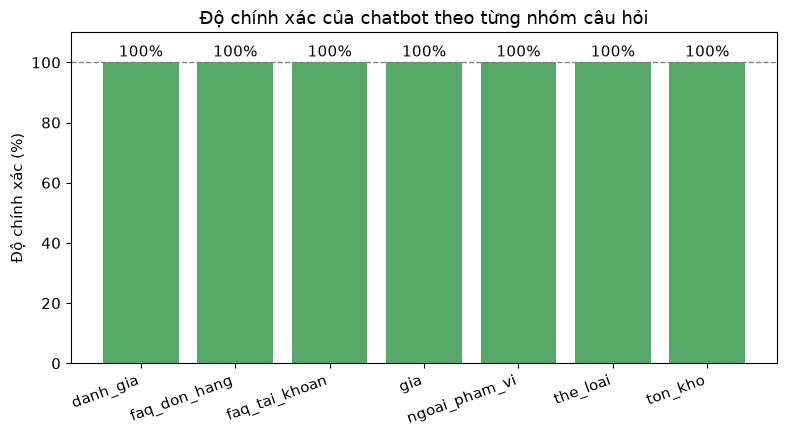

In [9]:
# Bieu do 2: độ chính xác theo từng nhóm câu hỏi
# (thay thế cho biểu đồ accuracy/loss qua từng epoch của CV/NLP)
plt.figure(figsize=(8, 4.5))
bars = plt.bar(accuracy_by_category.index, accuracy_by_category.values, color="#55A868")
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Độ chính xác của chatbot theo từng nhóm câu hỏi")
plt.ylabel("Độ chính xác (%)")
plt.ylim(0, 110)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, accuracy_by_category.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 2, f"{value:.0f}%", ha="center")

plt.tight_layout()
plt.show()


## 6. Thời gian phản hồi (latency)

Không có "loss qua epoch" để vẽ, nhưng thời gian phản hồi là 1 chỉ số vận hành quan trọng đáng trực quan hoá
cho 1 chatbot thực tế — cho biết trải nghiệm người dùng nhanh/chậm ra sao.

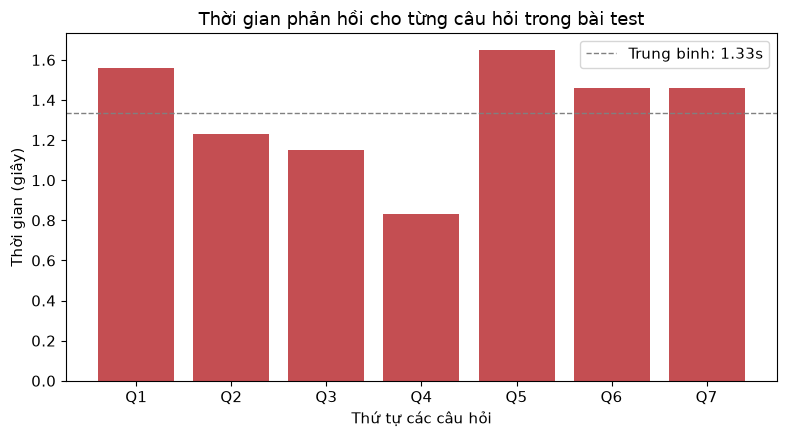

In [10]:
plt.figure(figsize=(8, 4.5))
plt.bar(range(len(df)), df["latency_sec"], color="#C44E52")
plt.title("Thời gian phản hồi cho từng câu hỏi trong bài test")
plt.xlabel("Thứ tự các câu hỏi")
plt.ylabel("Thời gian (giây)")
plt.xticks(range(len(df)), [f"Q{i+1}" for i in range(len(df))])
plt.axhline(df["latency_sec"].mean(), color="gray", linestyle="--", linewidth=1,
            label=f"Trung binh: {df['latency_sec'].mean():.2f}s")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Nhận xét & kết luận

*(Bạn tự viết phần này dựa trên kết quả thực tế chạy được ở trên — đây là phần Ban giám khảo hay hỏi nhất)*

Gợi ý các câu cần trả lời được:
- Nhóm câu hỏi nào chatbot trả lời tốt nhất / kém nhất? Vì sao?
- Nếu có câu sai, nguyên nhân là do **retrieval** (tìm sai đoạn) hay do **generation** (tìm đúng đoạn nhưng
  Gemini diễn đạt sai/thiếu)? Cách kiểm tra: xem cột `answer` ở bảng mục 4, đối chiếu với nội dung tài liệu gốc.
- Câu hỏi `ngoai_pham_vi` có được từ chối đúng cách không (trả lời "tài liệu không có thông tin" thay vì bịa)?
- Thời gian phản hồi trung bình có chấp nhận được cho trải nghiệm người dùng thực tế không?
- Nếu được làm lại/cải thiện thêm, bạn sẽ điều chỉnh gì? (VD: đổi `top_k`, đổi kích thước chunk, viết lại
  prompt, bổ sung thêm dữ liệu cho nhóm câu hỏi bị sai...)
